# 02 — Pré-processamento e Engenharia de Features

**Objetivo:** Transformar os dados brutos da EDA em um dataset pronto para modelagem.

**Etapas:**
1. Carregar dados brutos
2. Tratar outliers (`var14` — clipping)
3. Criar flag `processo_ativo`
4. Aplicar shift de -60 min no TARGET (horizonte de previsão de 1h)
5. Tratar valores ausentes (interpolação + forward-fill)
6. Criar features de tempo (hora cíclica, dia da semana)
7. Criar lags e médias móveis
8. Split treino/teste temporal
9. Salvar dataset processado

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configurações
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (14, 4)
sns.set_theme(style='darkgrid')

RAW_DATA_PATH = Path('../data/raw/dados_planta.csv')
PROCESSED_PATH = Path('../data/processed/')
PROCESSED_PATH.mkdir(parents=True, exist_ok=True)

TARGET_COL = 'TARGET'
TS_COL = 'TS'

FEATURE_COLS = ['var1','var2','var3','var4','var5','var6',
                'var8','var9','var10','var11','var12','var13','var14','var15']

print('Imports OK')

Imports OK


---
## 1. Carregar dados brutos

In [44]:
df = pd.read_csv(
    RAW_DATA_PATH,
    parse_dates=[TS_COL]
)

# Normalizar timezone para UTC e remover tzinfo (simplifica operações)
df[TS_COL] = pd.to_datetime(df[TS_COL], utc=True).dt.tz_localize(None)
df = df.sort_values(TS_COL).reset_index(drop=True)
df = df.set_index(TS_COL)

print(f'Shape: {df.shape}')
print(f'Período: {df.index.min()} → {df.index.max()}')
df.head(3)

Shape: (132478, 15)
Período: 2025-10-01 04:00:00 → 2026-01-01 04:00:00


,var1,var2,var3,var4,var5,var6,TARGET,var8,var9,var10,var11,var12,var13,var14,var15
TS,,,,,,,,,,,,,,,
2025-10-01 04:00:00,76.81861,285.6980,8.170019,149.5193,661.6836,97.57860,16.62272,430.2026,382.2714,76.08504,12.6,7.1,321.644226,34.54060,194.33432
2025-10-01 04:01:00,77.42704,287.4132,8.170019,149.5193,672.5122,97.43076,16.62272,433.6684,382.2714,76.08504,12.6,7.1,321.644226,36.34872,184.86020
2025-10-01 04:02:00,76.88915,284.2981,7.987461,149.5193,697.9288,97.29041,16.62272,431.0560,381.5530,76.08504,12.6,7.1,321.644226,35.49091,191.93140


---
## 2. Tratamento de outliers — `var14`

`var14` apresentou escala de 10⁷ e correlação de -0,01 com o TARGET. Aplicamos clipping nos percentis 1–99 para neutralizar valores extremos sem descartar a variável completamente.

In [45]:
p01 = df['var14'].quantile(0.01)
p99 = df['var14'].quantile(0.99)
print(f'var14 — p01: {p01:.2f} | p99: {p99:.2f}')
print(f'var14 — min antes: {df["var14"].min():.2f} | max antes: {df["var14"].max():.2f}')

df['var14'] = df['var14'].clip(lower=p01, upper=p99)

print(f'var14 — min depois: {df["var14"].min():.2f} | max depois: {df["var14"].max():.2f}')

var14 — p01: -1415.88 | p99: 94334.13
var14 — min antes: -36143610.00 | max antes: 21181090.00
var14 — min depois: -1415.88 | max depois: 94334.13


Vamos descartar essa variavel pois ela não acrescentará informações uteis para o modelo

In [46]:
# var14 tem correlação = -0.01 com TARGET e comportamento de sensor com falha
# Descartando da análise
df = df.drop(columns=['var14'])
FEATURE_COLS = [c for c in FEATURE_COLS if c != 'var14']
print(f"var14 removida. Features restantes: {len(FEATURE_COLS)}")
print(FEATURE_COLS)

var14 removida. Features restantes: 13
['var1', 'var2', 'var3', 'var4', 'var5', 'var6', 'var8', 'var9', 'var10', 'var11', 'var12', 'var13', 'var15']


---
## 3. Flag `processo_ativo`

A distribuição bimodal do TARGET (EDA) revelou dois estados: parado (TARGET ≈ 0) e em regime (TARGET ≈ 15–17).
Criamos uma flag binária para separar os dois estados. O threshold é definido como `TARGET > 1.0` para capturar apenas valores de parada sistêmica.

In [47]:
ACTIVE_THRESHOLD = 1.0

df['processo_ativo'] = (df[TARGET_COL] > ACTIVE_THRESHOLD).astype(int)

print(f'Distribuição da flag:')
print(df['processo_ativo'].value_counts())
print(f'\n% Ativo: {df["processo_ativo"].mean()*100:.1f}%')
print(f'% Parado: {(1 - df["processo_ativo"].mean())*100:.1f}%')

Distribuição da flag:
processo_ativo
1    130806
0      1672
Name: count, dtype: int64

% Ativo: 98.7%
% Parado: 1.3%


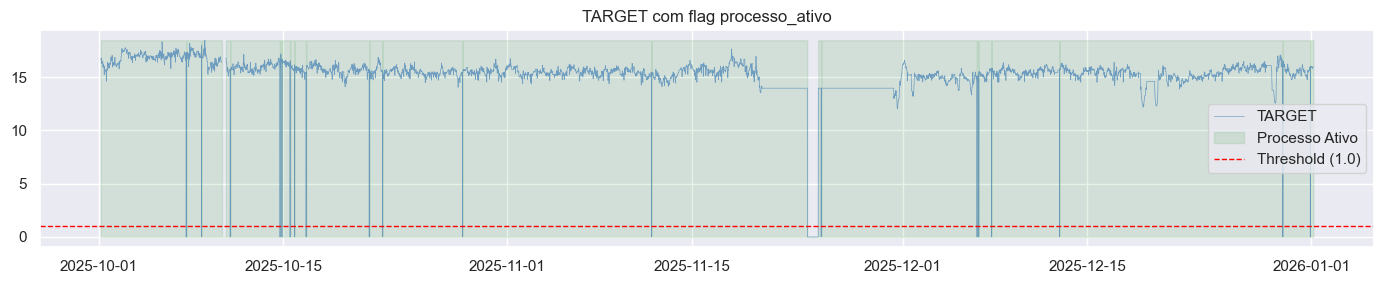

In [48]:
# Verificação visual
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(df.index, df[TARGET_COL], color='steelblue', lw=0.5, alpha=0.7, label='TARGET')
ax.fill_between(df.index, 0, df['processo_ativo'] * df[TARGET_COL].max(),
                color='green', alpha=0.1, label='Processo Ativo')
ax.axhline(ACTIVE_THRESHOLD, color='red', linestyle='--', lw=1, label=f'Threshold ({ACTIVE_THRESHOLD})')
ax.set_title('TARGET com flag processo_ativo')
ax.legend()
plt.tight_layout()
plt.show()

A separação é "correta" porque nenhum ponto de operação normal cai abaixo de 1,0 e nenhuma parada fica acima de 1,0. O threshold poderia ser 0,5 ou 5 e daria o mesmo resultado 
 qualquer valor nesse intervalo vazio funciona igualmente.

---
## 4. Shift do TARGET — horizonte de previsão de 1 hora

O desafio exige previsibilidade de 1 hora. Isso significa que o modelo deve aprender:
> *"Dado o estado do processo em t=0, qual será o TARGET em t=+60 minutos?"*

Implementamos isso deslocando o TARGET 60 posições para trás (shift=-60), de modo que cada linha contenha o valor futuro como variável resposta.

In [49]:
HORIZON = 60  # minutos

df['target_futuro'] = df[TARGET_COL].shift(-HORIZON)
df['processo_ativo_futuro'] = df['processo_ativo'].shift(-HORIZON)

print(f'Linhas com target_futuro nulo (últimas {HORIZON}): {df["target_futuro"].isna().sum()}')
df[['target_futuro', 'processo_ativo_futuro']].head(3)


Linhas com target_futuro nulo (últimas 60): 490


,target_futuro,processo_ativo_futuro
TS,,
2025-10-01 04:00:00,16.77736,1.0
2025-10-01 04:01:00,16.77736,1.0
2025-10-01 04:02:00,16.77736,1.0


---
## 5.1 Impacto da imputação na correlação com o TARGET

Fiz uma imputação prévia mas valores nulos são melhores tratados com dropna()

No entanto, em problemas de manutenção preditiva, nós não estamos preocupados com a média, estamos preocupados com as anomalias extremas. Congelar o valor de um sensor (ffill longo) durante um evento de pré-queda criaria um 'ponto cego' fatal para o algoritmo.

In [50]:
# ==========================================================
# TRATAMENTO DE VALORES AUSENTES (Estratégia Híbrida)
# ==========================================================
print(f"Total de linhas antes do tratamento: {len(df)}")

# 1. Preenchimento inercial curto (máximo de 5 minutos)
# Salva pequenas falhas de comunicação de rede sem criar dados artificiais longos
df = df.ffill(limit=5)

# 2. Remoção de apagões longos e pontas soltas
# Remove qualquer buraco maior que 5 min e as últimas 60 linhas geradas pelo shift(-60).
# Isso garante a integridade 100% real dos dados que vão para o modelo.
df = df.dropna()

print(f"Total de linhas após ffill(limit=5) e dropna: {len(df)}")

Total de linhas antes do tratamento: 132478
Total de linhas após ffill(limit=5) e dropna: 131890


---
## 6. Features de tempo

A EDA identificou **sazonalidade diária** (queda do TARGET na hora 0). Usamos codificação cíclica (seno/cosseno) para que o modelo entenda que 23h e 0h são próximas.

In [51]:
# Hora do dia — cíclica
hour = df.index.hour
df['hora_sin'] = np.sin(2 * np.pi * hour / 24)
df['hora_cos'] = np.cos(2 * np.pi * hour / 24)

# Minuto relativo no dia (0-1439)
minute_of_day = df.index.hour * 60 + df.index.minute
df['minuto_sin'] = np.sin(2 * np.pi * minute_of_day / 1440)
df['minuto_cos'] = np.cos(2 * np.pi * minute_of_day / 1440)

# Dia da semana (a EDA mostrou impacto baixo, mas incluímos)
dow = df.index.dayofweek
df['dow_sin'] = np.sin(2 * np.pi * dow / 7)
df['dow_cos'] = np.cos(2 * np.pi * dow / 7)

print('Features de tempo criadas:')
print(['hora_sin', 'hora_cos', 'minuto_sin', 'minuto_cos', 'dow_sin', 'dow_cos'])
df[['hora_sin', 'hora_cos', 'minuto_sin', 'minuto_cos']].head(5)

Features de tempo criadas:
['hora_sin', 'hora_cos', 'minuto_sin', 'minuto_cos', 'dow_sin', 'dow_cos']


,hora_sin,hora_cos,minuto_sin,minuto_cos
TS,,,,
2025-10-01 04:00:00,0.866025,0.5,0.866025,0.500000
2025-10-01 04:01:00,0.866025,0.5,0.868199,0.496217
2025-10-01 04:02:00,0.866025,0.5,0.870356,0.492424
2025-10-01 04:03:00,0.866025,0.5,0.872496,0.488621
2025-10-01 04:04:00,0.866025,0.5,0.874620,0.484810


---
## 7. Lags e médias móveis

Criamos lags e rolling means para as features mais correlacionadas com o TARGET.

| Tipo | Janelas | Motivo |
|---|---|---|
| Lag | 1, 5, 10, 30, 60 min | Captura tendência de curto e médio prazo |
| Rolling mean | 5, 15, 30 min | Suaviza ruído e captura nível médio |

In [52]:
# [SINCRONIZACAO SOURCE]: Removidos lags 1 e 5 para prevencao da Ilusao do Sensor (hardware stutter de 30min)
# [ATUALIZAÇÃO MLOps]: Substituído .mean() por .median() para blindagem contra outliers elétricos de 1 min
# Features selecionadas para lag/rolling (top correlação + TARGET original)
LAG_FEATURES = ['var4', 'var6', 'var2', 'var10', 'var13', 'var15', 'var1', TARGET_COL]
LAG_WINDOWS = [10, 30, 60, 90]
ROLLING_WINDOWS = [5, 15, 30]

print(f'Criando lags: {LAG_WINDOWS} min para {len(LAG_FEATURES)} features...')
for feat in LAG_FEATURES:
    for lag in LAG_WINDOWS:
        df[f'{feat}_lag{lag}'] = df[feat].shift(lag)

print(f'Criando rolling means: {ROLLING_WINDOWS} min para {len(LAG_FEATURES)} features...')
for feat in LAG_FEATURES:
    for window in ROLLING_WINDOWS:
        df[f'{feat}_roll{window}'] = df[feat].rolling(window=window, min_periods=1).median()

lag_cols = [c for c in df.columns if '_lag' in c or '_roll' in c]
print(f'\nTotal de features de lag/rolling criadas: {len(lag_cols)}')

Criando lags: [10, 30, 60, 90] min para 8 features...
Criando rolling means: [5, 15, 30] min para 8 features...

Total de features de lag/rolling criadas: 56


---
## 8. Limpeza final e split treino/teste

- Remove linhas com `target_futuro` nulo (último horizonte)
- Split temporal: **últimas 2 semanas como teste** — nunca misturar futuro no treino

In [55]:
# Remover linhas sem target futuro (últimas 60 linhas)
df = df.dropna(subset=['target_futuro'])

# Remover linhas com nulos nas primeiras janelas de lag
# (as primeiras 60 linhas terão NaN nos lags maiores)
df = df.dropna(subset=[f'{TARGET_COL}_lag60'])

df = df.dropna()

print(f'Shape após limpeza final: {df.shape}')
print(f'Período: {df.index.min()} → {df.index.max()}')

Shape após limpeza final: (131800, 79)
Período: 2025-10-01 05:30:00 → 2026-01-01 03:05:00


In [59]:
# Split temporal: últimas 2 semanas = teste
TEST_CUTOFF = df.index.max() - pd.Timedelta(weeks=2)
print(f'Cutoff: {TEST_CUTOFF}')

df_train = df[df.index <= TEST_CUTOFF].copy()
df_test  = df[df.index >  TEST_CUTOFF].copy()

print(f'Treino: {df_train.shape} | {df_train.index.min()} → {df_train.index.max()}')
print(f'Teste:  {df_test.shape}  | {df_test.index.min()} → {df_test.index.max()}')

# Verificação: sem vazamento de dados
assert df_train.index.max() < df_test.index.min(), 'Vazamento de dados detectado!'
print('\nSplit OK — sem vazamento de dados.')



Cutoff: 2025-12-18 03:05:00
Treino: (111640, 79) | 2025-10-01 05:30:00 → 2025-12-18 03:05:00
Teste:  (20160, 79)  | 2025-12-18 03:06:00 → 2026-01-01 03:05:00

Split OK — sem vazamento de dados.


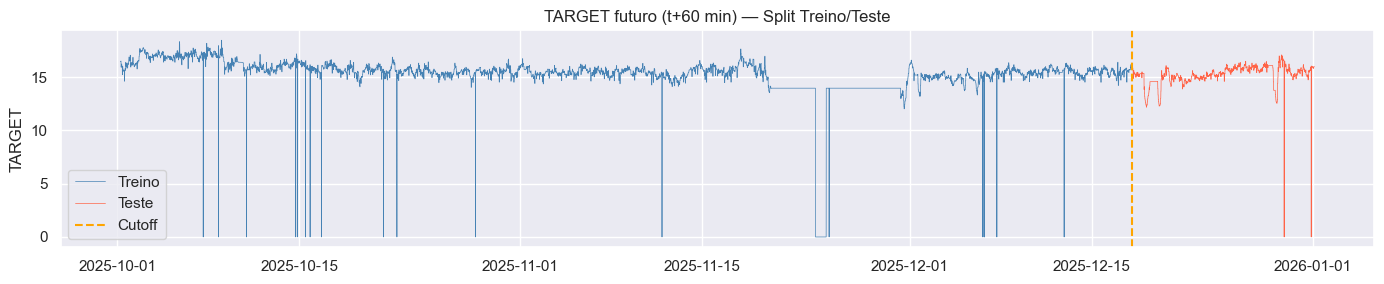

In [60]:
# Visualização do split
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(df_train.index, df_train['target_futuro'], color='steelblue', lw=0.5, label='Treino')
ax.plot(df_test.index, df_test['target_futuro'], color='tomato', lw=0.5, label='Teste')
ax.axvline(TEST_CUTOFF, color='orange', linestyle='--', lw=1.5, label='Cutoff')
ax.set_title('TARGET futuro (t+60 min) — Split Treino/Teste')
ax.set_ylabel('TARGET')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Salvar datasets processados

In [62]:
df_train.to_parquet(PROCESSED_PATH / 'train.parquet')
df_test.to_parquet(PROCESSED_PATH / 'test.parquet')
df.to_parquet(PROCESSED_PATH / 'full_processed.parquet')

print('Datasets salvos em data/processed/:')
print(f'  train.parquet         :{df_train.shape}')
print(f'  test.parquet          : {df_test.shape}')
print(f'  full_processed.parquet : {df.shape}')

Datasets salvos em data/processed/:
  train.parquet         :(111640, 79)
  test.parquet          : (20160, 79)
  full_processed.parquet : (131800, 79)


---
## 10. Resumo das features criadas

In [63]:
feature_summary = {
    'Features originais': FEATURE_COLS,
    'Features de tempo': ['hora_sin', 'hora_cos', 'minuto_sin', 'minuto_cos', 'dow_sin', 'dow_cos'],
    'Flag processo': ['processo_ativo'],
    'Lags': [c for c in df.columns if '_lag' in c],
    'Rolling means': [c for c in df.columns if '_roll' in c],
    'Target original': [TARGET_COL],
    'TARGET (variável resposta)': ['target_futuro'],
}

for group, cols in feature_summary.items():
    print(f'{group}: {len(cols)} features')

total = sum(len(v) for k, v in feature_summary.items() if k != 'TARGET (variável resposta)')
print(f'\nTotal de features preditoras: {total}')

Features originais: 13 features
Features de tempo: 6 features
Flag processo: 1 features
Lags: 32 features
Rolling means: 24 features
Target original: 1 features
TARGET (variável resposta): 1 features

Total de features preditoras: 77


---
## 11. Correlação das features engenheiradas com o target

Valida quais lags, médias móveis e features de tempo têm maior poder preditivo em relação ao `target_futuro`.

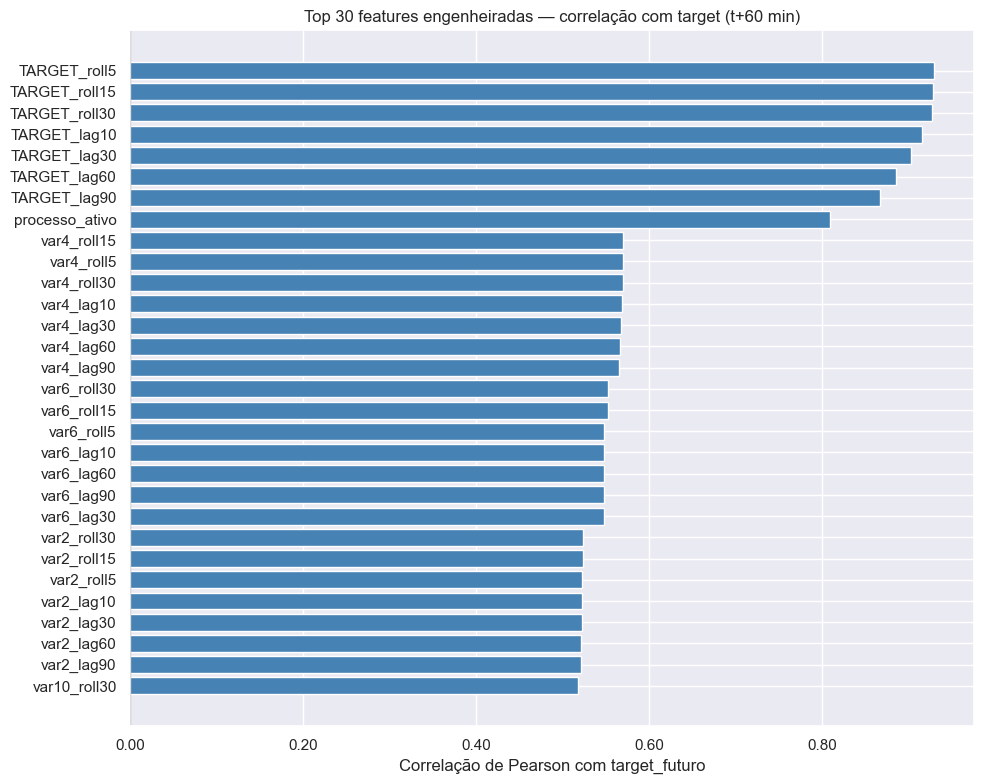


Top 10 features mais correlacionadas:
TARGET_roll5     +0.9291
TARGET_roll15    +0.9281
TARGET_roll30    +0.9275
TARGET_lag10     +0.9149
TARGET_lag30     +0.9030
TARGET_lag60     +0.8854
TARGET_lag90     +0.8674
processo_ativo   +0.8091
var4_roll15      +0.5697
var4_roll5       +0.5696


In [64]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Colunas de features engenheiradas (lags, rolling, tempo, flag)
_eng_cols = (
    [c for c in df_train.columns if '_lag' in c]
    + [c for c in df_train.columns if '_roll' in c]
    + ['hora_sin', 'hora_cos', 'minuto_sin', 'minuto_cos', 'dow_sin', 'dow_cos']
    + ['processo_ativo']
)

# Correlação de Pearson com target_futuro (calculada apenas no treino)
_corr = (
    df_train[_eng_cols]
    .corrwith(df_train['target_futuro'])
    .dropna()
    .sort_values(key=abs, ascending=False)
)

TOP_N = 30
_corr_top = _corr.iloc[:TOP_N]

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['steelblue' if v >= 0 else 'tomato' for v in _corr_top.values]
ax.barh(_corr_top.index[::-1], _corr_top.values[::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlação de Pearson com target_futuro')
ax.set_title(f'Top {TOP_N} features engenheiradas — correlação com target (t+60 min)')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
plt.tight_layout()
plt.show()

print(f'\nTop 10 features mais correlacionadas:')
print(_corr.head(10).to_string(float_format=lambda x: f'{x:+.4f}'))


---
## Próximos passos — `03_modeling.ipynb`

1. Separar `X_train`, `y_train`, `X_test`, `y_test`.
2. Treinar baseline (Naive — prever TARGET atual como futuro).
3. Treinar modelos rápidos: LightGBM, Random Forest, Linear Regression.
4. Usar `TimeSeriesSplit` para cross-validation.
5. Comparar métricas: **RMSE, MAE, MAPE**.
6. Analisar feature importance para validar hipóteses da EDA.